In [19]:
from skimage import io, filters, morphology, measure, segmentation, color
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from scipy import ndimage




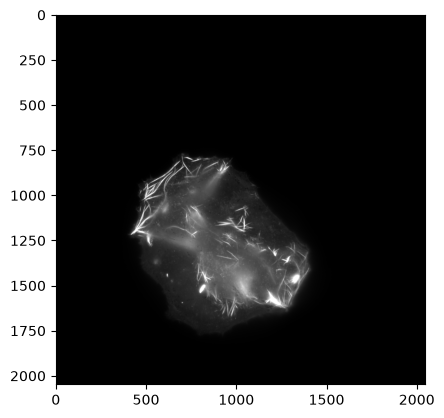

In [20]:
plt.imshow(test_image1, cmap='gray')

Tried to use white_tophat for background subtraction but it ended up removing the bright bundles and skipping it entirely fixed the problem

footprint = morphology.disk(5)

test_im_wtop = morphology.white_tophat(test_im_gaus, footprint)

In [138]:
test_image1 = io.imread("/Users/tylermoore/Main_Workspaces/Main/Cell_im_data/extracted/Test_im/Test_im1.png", as_gray=True)

def clean(image):
    #gausian filter for img smoothing
    image_gaus = filters.gaussian(image, sigma=1)

    #background subtraction
    image_filter = filters.sato(image_gaus,sigmas=range(1,4), black_ridges=False)

    #enhancement by creating a binary array
    thresh = np.percentile(image_filter, 98.5)
    binary_image = image_filter > thresh

    #removing small defects
    binary_image = morphology.remove_small_objects(binary_image, max_size=15)
    plt.imshow(binary_image, cmap='gray')


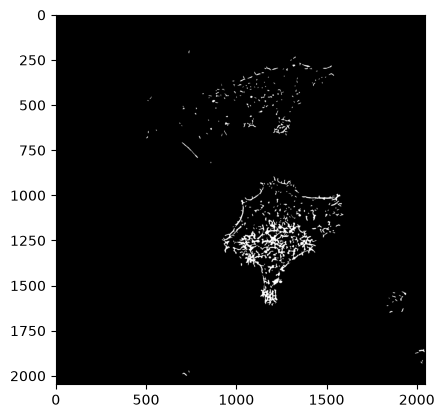

In [145]:
clean(io.imread("/Users/tylermoore/Main_Workspaces/Main/Cell_im_data/extracted/Test_im/Test_im2.png",as_gray=True))

Text(0.5, 1.0, 'changed')

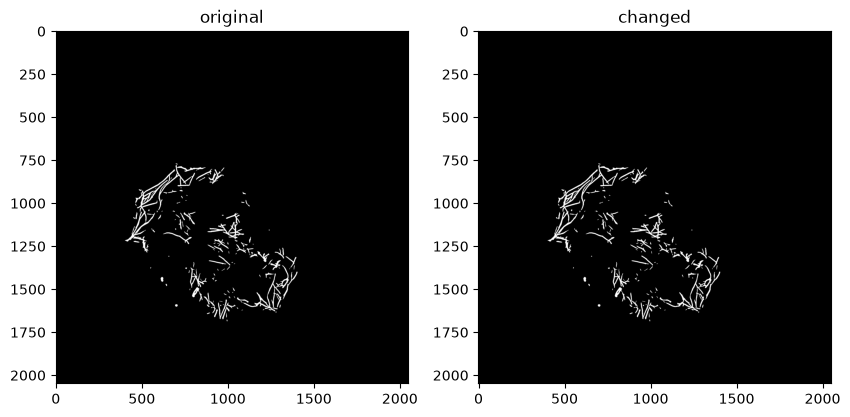

In [133]:
binary_10 = morphology.remove_small_objects(binary_image, max_size=10)
binary_15 = morphology.remove_small_objects(binary_image, max_size=15)

fig, axes = plt.subplots(1,2, figsize=(10,5))

axes[0].imshow(binary_10, cmap='gray')
axes[0].set_title("original")

axes[1].imshow(binary_15, cmap='gray')
axes[1].set_title("changed")


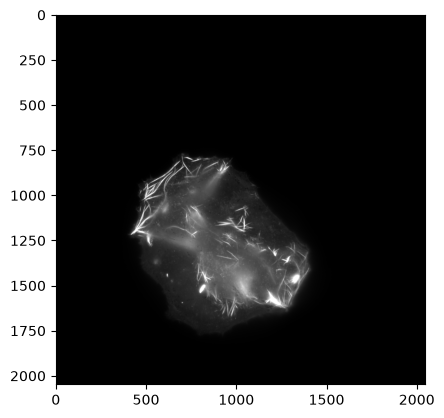

In [125]:

plt.imshow(test_image1, cmap='gray')